In [99]:
# Imports
# ----------------------------------------------------
import pandas as pd
import os
from datetime import datetime, timedelta
import pytz
from pytz import timezone
import matplotlib.pyplot as plt
from timezonefinderL import TimezoneFinder
import numpy as np
from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
from scipy.stats import gaussian_kde

In [51]:
# Getting flight data
# ----------------------------------------------------

# Getting file directory
base_dir = os.getcwd()

# Loading first month
sw_data_og = pd.read_csv(base_dir+"\\..\\..\\sw_data\\2023-01-31.csv")

# Checking if data loaded properly
print(sw_data_og.head())

C:\Users\abrah\AppData\Local\Temp\ipykernel_12584\1706994983.py:8: DtypeWarning: Columns (12,16,17,31,39,52,108,109,110,111,112,113,114,138,139,143,146) have mixed types. Specify dtype option on import or set low_memory=False.
  sw_data_og = pd.read_csv(base_dir+"\\..\\..\\sw_data\\2023-01-31.csv")


                       FLT_KEY ORIG_STN_CDE DEST_STN_CDE     SCHD_ARR_CENT_TS  \
0  2023-01-01_0169_WN007_WN121        WN007        WN121  2023-01-01 09:35:00   
1  2023-01-01_2382_WN080_WN133        WN080        WN133  2023-01-01 08:15:00   
2  2023-01-01_1054_WN080_WN005        WN080        WN005  2023-01-01 08:15:00   
3  2023-01-01_2280_WN018_WN116        WN018        WN116  2023-01-01 08:35:00   
4  2023-01-01_3067_WN013_WN052        WN013        WN052  2023-01-01 10:00:00   

      SCHD_DEP_CENT_TS     ACTL_ARR_CENT_TS    ACTL_DEPT_CENT_TS  \
0  2023-01-01 05:45:00  2023-01-01 10:06:00  2023-01-01 06:17:00   
1  2023-01-01 06:45:00  2023-01-01 10:05:00  2023-01-01 07:20:00   
2  2023-01-01 06:45:00  2023-01-01 10:32:00  2023-01-01 08:45:00   
3  2023-01-01 06:45:00  2023-01-01 08:52:00  2023-01-01 07:00:00   
4  2023-01-01 07:45:00  2023-01-01 10:55:00  2023-01-01 08:37:00   

    SCHD_OFFGR_CENT_TS    SCHD_ONGR_CENT_TS   ACTL_OFFGR_CENT_TS  ...  \
0  2023-01-01 05:57:00  2023-01

In [17]:
# Getting metar data
# ----------------------------------------------------

# Getting file directory
base_dir = os.getcwd()

# Loading metar 2023 WN032 data
metar_data = pd.read_csv(base_dir+"\\..\\..\\metar_data\\WN032_2023.csv",
                        usecols=[
                            "DATE", "WND", "CIG", "VIS", 
                            "TMP", "DEW", "SLP"
                        ]) # Excluding airport PII data

# Checking if data loaded properly
print(metar_data.head())

                  DATE             WND          CIG           VIS      TMP  \
0  2023-01-01T00:00:00  130,1,N,0036,1  22000,1,9,N  016000,1,9,9  +0011,1   
1  2023-01-01T00:53:00  140,5,N,0031,5  22000,5,9,N  016093,5,N,5  +0017,5   
2  2023-01-01T01:53:00  140,5,N,0036,5  22000,5,9,N  016093,5,N,5  +0011,5   
3  2023-01-01T02:53:00  130,5,N,0026,5  03048,5,M,N  016093,5,N,5  +0000,5   
4  2023-01-01T03:00:00  130,1,N,0026,1  99999,9,9,N  016000,1,9,9  +0000,1   

       DEW      SLP  
0  -0022,1  10061,1  
1  -0028,5  10067,5  
2  -0039,5  10072,5  
3  -0044,5  10077,5  
4  -0044,1  10077,1  


In [79]:
# Getting transtats data
# ----------------------------------------------------

# Loading Transtats data 156 (first month of 2023)
tnst_data = pd.read_csv(base_dir+"\\..\\..\\sw_data\\T_ONTIME_REPORTING_2023_1.csv",
                        dtype={"DEP_TIME": str, "CRS_DEP_TIME": str,
                        "ARR_TIME": str, "CRS_ARR_TIME": str})
tnst_data = tnst_data[tnst_data["ORIGIN"] == "DEN"]

In [34]:
# Localizing flight scheduled departure data to central time
# & Extracting only WN032 data
# ----------------------------------------------------

# Extracting WN032 data
sw_data = sw_data_og[sw_data_og["ORIG_STN_CDE"] == "WN032"]

# Getting central time zone instance
central_tz = timezone("US/Central")

# Making departure times into datetime objects
sw_data["ACTL_DEPT_CENT_TS"] = pd.to_datetime(sw_data["ACTL_DEPT_CENT_TS"])
sw_data["SCHD_DEP_CENT_TS"] = pd.to_datetime(sw_data["SCHD_DEP_CENT_TS"])

# Localizing to central time
sw_data["ACTL_DEPT_CENT_TS"] = sw_data["ACTL_DEPT_CENT_TS"].dt.tz_localize(central_tz)
sw_data["SCHD_DEP_CENT_TS"] = sw_data["SCHD_DEP_CENT_TS"].dt.tz_localize(central_tz)

# Dropping any NaN rows for departure
sw_data.dropna(subset=["ACTL_DEPT_CENT_TS"], inplace=True)

C:\Users\abrah\AppData\Local\Temp\ipykernel_12584\2777159577.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sw_data["ACTL_DEPT_CENT_TS"] = pd.to_datetime(sw_data["ACTL_DEPT_CENT_TS"])
C:\Users\abrah\AppData\Local\Temp\ipykernel_12584\2777159577.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sw_data["SCHD_DEP_CENT_TS"] = pd.to_datetime(sw_data["SCHD_DEP_CENT_TS"])
C:\Users\abrah\AppData\Local\Temp\ipykernel_12584\2777159577.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

In [35]:
# Localizing metar data to central time
# ----------------------------------------------------

# Creating central time date column
metar_data["DATE_CENT"] = (
    pd.to_datetime(metar_data["DATE"], utc=True)
    .dt.tz_convert("US/Central")
)

In [80]:
# Localizing transtats data to central time
# ----------------------------------------------------

# Crating instance of TimezoneFinder (using light version)
tf = TimezoneFinder()

# Getting central time zone instance
central_tz = timezone("US/Central")

# Load IATA to ICAO/Latitude/Longitude mapping
iata_icao = pd.read_csv(base_dir+"\\iata-icao.csv")
iata_to_icao = dict(zip(iata_icao["iata"], iata_icao["icao"]))
iata_to_latitude = dict(zip(iata_icao["iata"], iata_icao["latitude"]))
iata_to_longitude = dict(zip(iata_icao["iata"], iata_icao["longitude"]))

# Adding ICAO/Latitude/Longitude columns using maps
tnst_data["ICAO"] = tnst_data["ORIGIN"].map(iata_to_icao)
tnst_data["LATITUDE"] = tnst_data["ORIGIN"].map(iata_to_latitude)
tnst_data["LONGITUDE"] = tnst_data["ORIGIN"].map(iata_to_longitude)

# Adding timezone
tnst_data["LOCAL_TIMEZONE"] = tnst_data.apply(
    lambda row: tf.timezone_at(lat=row["LATITUDE"], lng=row["LONGITUDE"]),
    axis=1
)

# Converting FL_DATE column to datetime & dropping NaN's
tnst_data["FL_DATE"] = pd.to_datetime(tnst_data["FL_DATE"], format="%m/%d/%Y %I:%M:%S %p")
tnst_data.dropna(subset=["FL_DATE", "CRS_DEP_TIME", "DEP_TIME", "CRS_ARR_TIME", "ARR_TIME"], inplace=True)

# Making actual departure time date column
tnst_data["ACTL_DEP_TIME_DATE"] = (
    tnst_data["FL_DATE"] +
    pd.to_timedelta(tnst_data["DEP_TIME"].str[:2].astype(int), unit="h") +
    pd.to_timedelta(tnst_data["DEP_TIME"].str[2:].astype(int), unit="m")
)
tnst_data["SCHD_DEP_TIME_DATE"] = (
    tnst_data["FL_DATE"] +
    pd.to_timedelta(tnst_data["CRS_DEP_TIME"].str[:2].astype(int), unit="h") +
    pd.to_timedelta(tnst_data["CRS_DEP_TIME"].str[2:].astype(int), unit="m")
)
tnst_data["ACTL_ARR_TIME_DATE"] = (
    tnst_data["FL_DATE"] +
    pd.to_timedelta(tnst_data["ARR_TIME"].str[:2].astype(int), unit="h") +
    pd.to_timedelta(tnst_data["ARR_TIME"].str[2:].astype(int), unit="m")
)
tnst_data["SCHD_ARR_TIME_DATE"] = (
    tnst_data["FL_DATE"] +
    pd.to_timedelta(tnst_data["CRS_ARR_TIME"].str[:2].astype(int), unit="h") +
    pd.to_timedelta(tnst_data["CRS_ARR_TIME"].str[2:].astype(int), unit="m")
)

# Adding 1 day if arrival < departure (means took off one day landed that next)
tnst_data["ACTL_ARR_TIME_DATE"] = np.where(
    tnst_data["ACTL_ARR_TIME_DATE"] < tnst_data["ACTL_DEP_TIME_DATE"],
    tnst_data["ACTL_ARR_TIME_DATE"] + pd.Timedelta(days=1),
    tnst_data["ACTL_ARR_TIME_DATE"]
)
tnst_data["SCHD_ARR_TIME_DATE"] = np.where(
    tnst_data["SCHD_ARR_TIME_DATE"] < tnst_data["SCHD_DEP_TIME_DATE"],
    tnst_data["SCHD_ARR_TIME_DATE"] + pd.Timedelta(days=1),
    tnst_data["SCHD_ARR_TIME_DATE"]
)

# Adding timezone awareness
tnst_data["ACTL_DEP_TIME_DATE"] = tnst_data.apply(
    lambda row: timezone(row["LOCAL_TIMEZONE"]).localize(row["ACTL_DEP_TIME_DATE"]),
    axis=1
)

tnst_data["SCHD_DEP_TIME_DATE"] = tnst_data.apply(
    lambda row: timezone(row["LOCAL_TIMEZONE"]).localize(row["SCHD_DEP_TIME_DATE"]),
    axis=1
)
tnst_data["ACTL_ARR_TIME_DATE"] = tnst_data.apply(
    lambda row: timezone(row["LOCAL_TIMEZONE"]).localize(row["ACTL_ARR_TIME_DATE"]),
    axis=1
)
tnst_data["SCHD_ARR_TIME_DATE"] = tnst_data.apply(
    lambda row: timezone(row["LOCAL_TIMEZONE"]).localize(row["SCHD_ARR_TIME_DATE"]),
    axis=1
)

# Converting to Central Time
tnst_data["ACTL_DEP_TIME_DATE_CENT"] = tnst_data["ACTL_DEP_TIME_DATE"].apply(lambda x: x.astimezone(central_tz))
tnst_data["SCHD_DEP_TIME_DATE_CENT"] = tnst_data["SCHD_DEP_TIME_DATE"].apply(lambda x: x.astimezone(central_tz))
tnst_data["ACTL_ARR_TIME_DATE_CENT"] = tnst_data["ACTL_ARR_TIME_DATE"].apply(lambda x: x.astimezone(central_tz))
tnst_data["SCHD_ARR_TIME_DATE_CENT"] = tnst_data["SCHD_ARR_TIME_DATE"].apply(lambda x: x.astimezone(central_tz))

# Removing NaN's and reseting index
tnst_data.dropna(subset=["FL_DATE", "CRS_DEP_TIME", "DEP_TIME", "CRS_ARR_TIME", "ARR_TIME"], inplace=True)
tnst_data.reset_index(inplace=True, drop=True)

# Showing results
print(tnst_data.head())

     FL_DATE  OP_CARRIER_AIRLINE_ID OP_CARRIER TAIL_NUM  OP_CARRIER_FL_NUM  \
0 2023-01-01                  19393         WN   N1806U               1622   
1 2023-01-01                  19393         WN   N1810U                813   
2 2023-01-01                  19393         WN   N207WN               3247   
3 2023-01-01                  19393         WN   N210WN               2304   
4 2023-01-01                  19393         WN   N211WN               3402   

  ORIGIN DEST CRS_DEP_TIME DEP_TIME CRS_ARR_TIME  ... LONGITUDE  \
0    DEN  SFO         2200     2257         2345  ...  -104.673   
1    DEN  TUS         1440     1523         1640  ...  -104.673   
2    DEN  MCO         1520     1550         2050  ...  -104.673   
3    DEN  MCI         1350     1441         1620  ...  -104.673   
4    DEN  SNA         0730     0725         0900  ...  -104.673   

   LOCAL_TIMEZONE        ACTL_DEP_TIME_DATE        SCHD_DEP_TIME_DATE  \
0  America/Denver 2023-01-01 22:57:00-07:00 2023-01-01 

In [82]:
# Downloading 2th month of transtats data for test benchs
# ----------------------------------------------------

# Loading Transtats data (any month of 2023)
tnst_data_tb = pd.read_csv(base_dir+"\\..\\..\\sw_data\\T_ONTIME_REPORTING_2023_2.csv",
                        dtype={"DEP_TIME": str, "CRS_DEP_TIME": str,
                        "ARR_TIME": str, "CRS_ARR_TIME": str})
tnst_data_tb = tnst_data_tb[tnst_data_tb["ORIGIN"] == "DEN"]

In [83]:
# Localizing 2th month of transtats data for test benchs
# ----------------------------------------------------

# Crating instance of TimezoneFinder (using light version)
tf = TimezoneFinder()

# Getting central time zone instance
central_tz = timezone("US/Central")

# Load IATA to ICAO/Latitude/Longitude mapping
iata_icao = pd.read_csv(base_dir+"\\iata-icao.csv")
iata_to_icao = dict(zip(iata_icao["iata"], iata_icao["icao"]))
iata_to_latitude = dict(zip(iata_icao["iata"], iata_icao["latitude"]))
iata_to_longitude = dict(zip(iata_icao["iata"], iata_icao["longitude"]))

# Adding ICAO/Latitude/Longitude columns using maps
tnst_data_tb["ICAO"] = tnst_data_tb["ORIGIN"].map(iata_to_icao)
tnst_data_tb["LATITUDE"] = tnst_data_tb["ORIGIN"].map(iata_to_latitude)
tnst_data_tb["LONGITUDE"] = tnst_data_tb["ORIGIN"].map(iata_to_longitude)

# Adding timezone
tnst_data_tb["LOCAL_TIMEZONE"] = tnst_data_tb.apply(
    lambda row: tf.timezone_at(lat=row["LATITUDE"], lng=row["LONGITUDE"]),
    axis=1
)

# Converting FL_DATE column to datetime & dropping NaN's
tnst_data_tb["FL_DATE"] = pd.to_datetime(tnst_data_tb["FL_DATE"], format="%m/%d/%Y %I:%M:%S %p")
tnst_data_tb.dropna(subset=["FL_DATE", "CRS_DEP_TIME", "DEP_TIME", "CRS_ARR_TIME", "ARR_TIME"], inplace=True)

# Making actual departure time date column
tnst_data_tb["ACTL_DEP_TIME_DATE"] = (
    tnst_data_tb["FL_DATE"] +
    pd.to_timedelta(tnst_data_tb["DEP_TIME"].str[:2].astype(int), unit="h") +
    pd.to_timedelta(tnst_data_tb["DEP_TIME"].str[2:].astype(int), unit="m")
)
tnst_data_tb["SCHD_DEP_TIME_DATE"] = (
    tnst_data_tb["FL_DATE"] +
    pd.to_timedelta(tnst_data_tb["CRS_DEP_TIME"].str[:2].astype(int), unit="h") +
    pd.to_timedelta(tnst_data_tb["CRS_DEP_TIME"].str[2:].astype(int), unit="m")
)
tnst_data_tb["ACTL_ARR_TIME_DATE"] = (
    tnst_data_tb["FL_DATE"] +
    pd.to_timedelta(tnst_data_tb["ARR_TIME"].str[:2].astype(int), unit="h") +
    pd.to_timedelta(tnst_data_tb["ARR_TIME"].str[2:].astype(int), unit="m")
)
tnst_data_tb["SCHD_ARR_TIME_DATE"] = (
    tnst_data_tb["FL_DATE"] +
    pd.to_timedelta(tnst_data_tb["CRS_ARR_TIME"].str[:2].astype(int), unit="h") +
    pd.to_timedelta(tnst_data_tb["CRS_ARR_TIME"].str[2:].astype(int), unit="m")
)

# Adding 1 day if arrival < departure (means took off one day landed that next)
tnst_data_tb["ACTL_ARR_TIME_DATE"] = np.where(
    tnst_data_tb["ACTL_ARR_TIME_DATE"] < tnst_data_tb["ACTL_DEP_TIME_DATE"],
    tnst_data_tb["ACTL_ARR_TIME_DATE"] + pd.Timedelta(days=1),
    tnst_data_tb["ACTL_ARR_TIME_DATE"]
)
tnst_data_tb["SCHD_ARR_TIME_DATE"] = np.where(
    tnst_data_tb["SCHD_ARR_TIME_DATE"] < tnst_data_tb["SCHD_DEP_TIME_DATE"],
    tnst_data_tb["SCHD_ARR_TIME_DATE"] + pd.Timedelta(days=1),
    tnst_data_tb["SCHD_ARR_TIME_DATE"]
)

# Adding timezone awareness
tnst_data_tb["ACTL_DEP_TIME_DATE"] = tnst_data_tb.apply(
    lambda row: timezone(row["LOCAL_TIMEZONE"]).localize(row["ACTL_DEP_TIME_DATE"]),
    axis=1
)

tnst_data_tb["SCHD_DEP_TIME_DATE"] = tnst_data_tb.apply(
    lambda row: timezone(row["LOCAL_TIMEZONE"]).localize(row["SCHD_DEP_TIME_DATE"]),
    axis=1
)
tnst_data_tb["ACTL_ARR_TIME_DATE"] = tnst_data_tb.apply(
    lambda row: timezone(row["LOCAL_TIMEZONE"]).localize(row["ACTL_ARR_TIME_DATE"]),
    axis=1
)
tnst_data_tb["SCHD_ARR_TIME_DATE"] = tnst_data_tb.apply(
    lambda row: timezone(row["LOCAL_TIMEZONE"]).localize(row["SCHD_ARR_TIME_DATE"]),
    axis=1
)

# Converting to Central Time
tnst_data_tb["ACTL_DEP_TIME_DATE_CENT"] = tnst_data_tb["ACTL_DEP_TIME_DATE"].apply(lambda x: x.astimezone(central_tz))
tnst_data_tb["SCHD_DEP_TIME_DATE_CENT"] = tnst_data_tb["SCHD_DEP_TIME_DATE"].apply(lambda x: x.astimezone(central_tz))
tnst_data_tb["ACTL_ARR_TIME_DATE_CENT"] = tnst_data_tb["ACTL_ARR_TIME_DATE"].apply(lambda x: x.astimezone(central_tz))
tnst_data_tb["SCHD_ARR_TIME_DATE_CENT"] = tnst_data_tb["SCHD_ARR_TIME_DATE"].apply(lambda x: x.astimezone(central_tz))

# Removing NaN's and reseting index
tnst_data_tb.dropna(subset=["FL_DATE", "CRS_DEP_TIME", "DEP_TIME", "CRS_ARR_TIME", "ARR_TIME"], inplace=True)
tnst_data_tb.reset_index(inplace=True, drop=True)

# Showing results
print(tnst_data_tb.head())

     FL_DATE  OP_CARRIER_AIRLINE_ID OP_CARRIER TAIL_NUM  OP_CARRIER_FL_NUM  \
0 2023-02-01                  19393         WN   N1801U               2212   
1 2023-02-01                  19393         WN   N1801U               2422   
2 2023-02-01                  19393         WN   N1808U                663   
3 2023-02-01                  19393         WN   N1809U               3107   
4 2023-02-01                  19393         WN   N1811U               2672   

  ORIGIN DEST CRS_DEP_TIME DEP_TIME CRS_ARR_TIME  ... LONGITUDE  \
0    DEN  LAS         2225     2313         2330  ...  -104.673   
1    DEN  MKE         1025     1025         1345  ...  -104.673   
2    DEN  DTW         1355     1359         1835  ...  -104.673   
3    DEN  ORD         1045     1229         1415  ...  -104.673   
4    DEN  TUS         0835     0832         1045  ...  -104.673   

   LOCAL_TIMEZONE        ACTL_DEP_TIME_DATE        SCHD_DEP_TIME_DATE  \
0  America/Denver 2023-02-01 23:13:00-07:00 2023-02-01 

In [84]:
# Building takeoff time split model using visibility & clouds
# ----------------------------------------------------

# Creating data copies
metar_datac = metar_data.copy()
sw_datac = sw_data.copy()
tnst_datac = tnst_data.copy()

# Removing up null data
metar_datac = metar_datac[metar_datac["CIG"].str[:5] != "99999"]
metar_datac = metar_datac[metar_datac["VIS"].str[:6] != "999999"]

# Converting to VIS & CIG to numeric
metar_datac["CIG"] = pd.to_numeric(metar_datac["CIG"].str[:5], errors="coerce")
metar_datac["VIS"] = pd.to_numeric(metar_datac["VIS"].str[:6], errors="coerce")
metar_datac.dropna(subset=["CIG", "VIS"], inplace=True)

# Sorting flight data by date time
tnst_datac.sort_values(by="ACTL_DEP_TIME_DATE_CENT", ascending=True, inplace=True)
tnst_datac.reset_index(drop=True, inplace=True)

# Merging metar_datac into tnst_datac
merged_datac = pd.merge_asof(
    tnst_datac,
    metar_datac,
    left_on="ACTL_DEP_TIME_DATE_CENT",
    right_on="DATE_CENT",
    direction="backward"
)

# Extracting key indices
key_indices = merged_datac.drop_duplicates(subset=["CIG", "VIS"], keep="last").dropna(subset=["CIG", "VIS"]).index.tolist()

# Adding average separation unit
merged_datac["AVG_SPLIT"] = (
    (merged_datac["ACTL_DEP_TIME_DATE_CENT"].shift(-1)-merged_datac["ACTL_DEP_TIME_DATE_CENT"]).dt.total_seconds() / 60
).rolling(10).mean()

# Singling out key indices
merged_datac["KEY_INDICE"] = merged_datac.index.isin(key_indices)

# Extracting split data form key indices
split_data = merged_datac[merged_datac["KEY_INDICE"] == True]["AVG_SPLIT"]

# Building distribution
mean = np.mean(split_data)
std_dev = np.std(split_data)

# Building Buckets
lower_0 = split_data.quantile(0.33)
middle_1 = split_data.quantile(0.66)
cut_points = [float("-inf"), lower_0, middle_1, float("inf")]
labels = [0, 1, 2]

# Classifying indices
merged_datac.loc[merged_datac["KEY_INDICE"], "BUCKET"] = pd.cut(
    merged_datac.loc[merged_datac["KEY_INDICE"], "AVG_SPLIT"],
    bins=cut_points,
    labels=labels
)

# Creating inputs for model
model_data = merged_datac.loc[merged_datac["KEY_INDICE"], ["CIG", "VIS", "BUCKET"]].copy()
model_data.dropna(inplace=True)

# Building features x and target y
X = model_data[["CIG", "VIS"]].values
y = model_data["BUCKET"].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=40, stratify=y
)

# Training KNN model
knn = KNeighborsClassifier(
    n_neighbors=3,
    weights="distance"
)
knn.fit(X_train, y_train)

# Evaluating model
y_pred = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Training XGBoost model
xgb_clf = XGBClassifier(
    n_estimators=50,     # number of trees
    max_depth=3,          # max depth of trees
    learning_rate=0.1,    # step size shrinkage
    use_label_encoder=False,
    eval_metric='mlogloss' # required to suppress warning
)
xgb_clf.fit(X_train, y_train)

# Evaluating model
y_pred = xgb_clf.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

KNN Accuracy: 0.4909090909090909
Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.55      0.51        20
           1       0.46      0.38      0.41        16
           2       0.53      0.53      0.53        19

    accuracy                           0.49        55
   macro avg       0.49      0.48      0.48        55
weighted avg       0.49      0.49      0.49        55

XGBoost Accuracy: 0.4727272727272727
Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.60      0.59        20
           1       0.36      0.31      0.33        16
           2       0.45      0.47      0.46        19

    accuracy                           0.47        55
   macro avg       0.46      0.46      0.46        55
weighted avg       0.47      0.47      0.47        55



c:\Users\abrah\Desktop\Projects\wi_environment\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:11:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [85]:
# Building visibility & clouds model test bench
# ----------------------------------------------------

# Creating data copies
metar_datac = metar_data.copy()
sw_datac = sw_data.copy()
tnst_datac = tnst_data_tb.copy()

# Removing up null data
metar_datac = metar_datac[metar_datac["CIG"].str[:5] != "99999"]
metar_datac = metar_datac[metar_datac["VIS"].str[:6] != "999999"]

# Converting to VIS & CIG to numeric
metar_datac["CIG"] = pd.to_numeric(metar_datac["CIG"].str[:5], errors="coerce")
metar_datac["VIS"] = pd.to_numeric(metar_datac["VIS"].str[:6], errors="coerce")
metar_datac.dropna(subset=["CIG", "VIS"], inplace=True)

# Sorting flight data by date time
tnst_datac.sort_values(by="ACTL_DEP_TIME_DATE_CENT", ascending=True, inplace=True)
tnst_datac.reset_index(drop=True, inplace=True)

# Merging metar_datac into tnst_datac
merged_datac = pd.merge_asof(
    tnst_datac,
    metar_datac,
    left_on="ACTL_DEP_TIME_DATE_CENT",
    right_on="DATE_CENT",
    direction="backward"
)

# Extracting key indices
key_indices = merged_datac.drop_duplicates(subset=["CIG"], keep="last").dropna(subset=["CIG"]).index.tolist()

# Adding average separation unit
merged_datac["AVG_SPLIT"] = (
    (merged_datac["ACTL_DEP_TIME_DATE_CENT"].shift(-1)-merged_datac["ACTL_DEP_TIME_DATE_CENT"]).dt.total_seconds() / 60
).rolling(10).mean()

# Singling out key indices
merged_datac["KEY_INDICE"] = merged_datac.index.isin(key_indices)

# Classifying indices
merged_datac.loc[merged_datac["KEY_INDICE"], "BUCKET"] = pd.cut(
    merged_datac.loc[merged_datac["KEY_INDICE"], "AVG_SPLIT"],
    bins=cut_points,
    labels=labels
)

# Creating inputs for model
model_data = merged_datac.loc[merged_datac["KEY_INDICE"], ["CIG", "VIS", "BUCKET"]].copy()
model_data.dropna(inplace=True)

# Building features x and target y
X = model_data[["CIG", "VIS"]].values
y = model_data["BUCKET"].values

# Evaluating model
y_pred = knn.predict(X)
print("KNN Accuracy:", accuracy_score(y, y_pred))
print("Classification Report:")
print(classification_report(y, y_pred))

# Evaluating model
y_pred = xgb_clf.predict(X)
print("XGBoost Accuracy:", accuracy_score(y, y_pred))
print("Classification Report:")
print(classification_report(y, y_pred))

KNN Accuracy: 0.3137254901960784
Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.26      0.29        19
           1       0.31      0.25      0.28        16
           2       0.32      0.44      0.37        16

    accuracy                           0.31        51
   macro avg       0.31      0.32      0.31        51
weighted avg       0.31      0.31      0.31        51

XGBoost Accuracy: 0.3333333333333333
Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.21      0.29        19
           1       0.36      0.31      0.33        16
           2       0.29      0.50      0.36        16

    accuracy                           0.33        51
   macro avg       0.36      0.34      0.33        51
weighted avg       0.37      0.33      0.33        51



In [86]:
# Building fog model using temperature, dew point, & wind speed
# ----------------------------------------------------

# building model
def fog_risk_model(temp, dew, wnd_spd):
    if (temp-dew < 2 and wnd_spd < 3):
        return 2
    elif (temp-dew < 3 and wnd_spd < 5):
        return 1
    else:
        return 0

In [87]:
# Building take off possibility model using wind speed, & wind direction
# ----------------------------------------------------

# Creating data copies
metar_datac = metar_data.copy()
sw_datac = sw_data.copy()
tnst_datac = tnst_data.copy()

# Removing up null data
metar_datac = metar_datac[metar_datac["WND"].str[:3] != "999"]

# Converting to VIS & CIG to numeric
metar_datac["WND_SPD"] = pd.to_numeric(metar_datac["WND"].str.split(",").str[3], errors="coerce")
metar_datac["WND_DIR"] = pd.to_numeric(metar_datac["WND"].str.split(",").str[0], errors="coerce")
metar_datac.dropna(subset=["WND_SPD", "WND_DIR"], inplace=True)

# Sorting flight data by date time
tnst_datac.sort_values(by="SCHD_DEP_TIME_DATE_CENT", ascending=True, inplace=True)
tnst_datac.reset_index(drop=True, inplace=True)

# Merging metar_datac into tnst_datac
merged_datac = pd.merge_asof(
    tnst_datac,
    metar_datac,
    left_on="SCHD_DEP_TIME_DATE_CENT",
    right_on="DATE_CENT",
    direction="backward"
)

# Extracting key indices
key_indices = merged_datac.drop_duplicates(subset=["WND_SPD", "WND_DIR"], keep="last").dropna(subset=["WND_SPD"]).index.tolist()

# Singling out key indices
merged_datac["KEY_INDICE"] = merged_datac.index.isin(key_indices)

# Classifying key indices
for indice in key_indices:
    i = indice
    threshold_t = merged_datac.iloc[i]["SCHD_DEP_TIME_DATE_CENT"] + timedelta(minutes=15)
    takeoff_cnt = 0
    if (i < len(merged_datac) and
           merged_datac.iloc[i]["ACTL_DEP_TIME_DATE_CENT"] < threshold_t and
           merged_datac.iloc[i]["SCHD_DEP_TIME_DATE_CENT"] >= merged_datac.iloc[indice]["SCHD_DEP_TIME_DATE_CENT"] and
           takeoff_cnt < 1):
        takeoff_cnt += 1
    
    merged_datac.at[indice, "TAKE_OFF"] = int(takeoff_cnt > 0)


# Creating inputs for model
model_data = merged_datac.loc[merged_datac["KEY_INDICE"], ["WND_SPD", "WND_DIR", "TAKE_OFF"]].copy()
model_data.dropna(inplace=True)

# Building features x and target y
X = model_data[["WND_SPD", "WND_DIR"]].values
y = model_data["TAKE_OFF"].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=45, stratify=y
)

# Training KNN model
knn = KNeighborsClassifier(
    n_neighbors=3,
    weights="distance"
)
knn.fit(X_train, y_train)

# Evaluating model
y_pred = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Training XGBoost model
xgb_clf = XGBClassifier(
    n_estimators=50,     # number of trees
    max_depth=3,          # max depth of trees
    learning_rate=0.1,    # step size shrinkage
    use_label_encoder=False,
    eval_metric='mlogloss' # required to suppress warning
)
xgb_clf.fit(X_train, y_train)

# Evaluating model
y_pred = xgb_clf.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

KNN Accuracy: 0.5846153846153846
Classification Report:
              precision    recall  f1-score   support

         0.0       0.33      0.35      0.34        20
         1.0       0.70      0.69      0.70        45

    accuracy                           0.58        65
   macro avg       0.52      0.52      0.52        65
weighted avg       0.59      0.58      0.59        65

XGBoost Accuracy: 0.7384615384615385
Classification Report:
              precision    recall  f1-score   support

         0.0       0.71      0.25      0.37        20
         1.0       0.74      0.96      0.83        45

    accuracy                           0.74        65
   macro avg       0.73      0.60      0.60        65
weighted avg       0.73      0.74      0.69        65



c:\Users\abrah\Desktop\Projects\wi_environment\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:12:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [88]:
# Building take off possibility model test bench
# ----------------------------------------------------

# Creating data copies
metar_datac = metar_data.copy()
sw_datac = sw_data.copy()
tnst_datac = tnst_data_tb.copy()

# Removing up null data
metar_datac = metar_datac[metar_datac["WND"].str[:3] != "999"]

# Converting to VIS & CIG to numeric
metar_datac["WND_SPD"] = pd.to_numeric(metar_datac["WND"].str.split(",").str[3], errors="coerce")
metar_datac["WND_DIR"] = pd.to_numeric(metar_datac["WND"].str.split(",").str[0], errors="coerce")
metar_datac.dropna(subset=["WND_SPD", "WND_DIR"], inplace=True)

# Sorting flight data by date time
tnst_datac.sort_values(by="SCHD_DEP_TIME_DATE_CENT", ascending=True, inplace=True)
tnst_datac.reset_index(drop=True, inplace=True)

# Merging metar_datac into tnst_datac
merged_datac = pd.merge_asof(
    tnst_datac,
    metar_datac,
    left_on="SCHD_DEP_TIME_DATE_CENT",
    right_on="DATE_CENT",
    direction="backward"
)

# Extracting key indices
key_indices = merged_datac.drop_duplicates(subset=["WND_SPD", "WND_DIR"], keep="last").dropna(subset=["WND_SPD"]).index.tolist()

# Singling out key indices
merged_datac["KEY_INDICE"] = merged_datac.index.isin(key_indices)

# Classifying key indices
for indice in key_indices:
    i = indice
    threshold_t = merged_datac.iloc[i]["SCHD_DEP_TIME_DATE_CENT"] + timedelta(minutes=15)
    takeoff_cnt = 0
    if (i < len(merged_datac) and
           merged_datac.iloc[i]["ACTL_DEP_TIME_DATE_CENT"] < threshold_t and
           merged_datac.iloc[i]["SCHD_DEP_TIME_DATE_CENT"] >= merged_datac.iloc[indice]["SCHD_DEP_TIME_DATE_CENT"] and
           takeoff_cnt < 1):
        takeoff_cnt += 1
    
    merged_datac.at[indice, "TAKE_OFF"] = int(takeoff_cnt > 0)


# Creating inputs for model
model_data = merged_datac.loc[merged_datac["KEY_INDICE"], ["WND_SPD", "WND_DIR", "TAKE_OFF"]].copy()
model_data.dropna(inplace=True)

# Building features x and target y
X = model_data[["WND_SPD", "WND_DIR"]].values
y = model_data["TAKE_OFF"].values

# Evaluating model
y_pred = knn.predict(X)
print("KNN Accuracy:", accuracy_score(y, y_pred))
print("Classification Report:")
print(classification_report(y, y_pred))

# Evaluating model
y_pred = xgb_clf.predict(X)
print("XGBoost Accuracy:", accuracy_score(y, y_pred))
print("Classification Report:")
print(classification_report(y, y_pred))

KNN Accuracy: 0.5638629283489096
Classification Report:
              precision    recall  f1-score   support

         0.0       0.26      0.27      0.26        93
         1.0       0.70      0.68      0.69       228

    accuracy                           0.56       321
   macro avg       0.48      0.48      0.48       321
weighted avg       0.57      0.56      0.57       321

XGBoost Accuracy: 0.6230529595015576
Classification Report:
              precision    recall  f1-score   support

         0.0       0.21      0.11      0.14        93
         1.0       0.70      0.83      0.76       228

    accuracy                           0.62       321
   macro avg       0.45      0.47      0.45       321
weighted avg       0.55      0.62      0.58       321



In [90]:
# Getting Data for National Air System Congestion model
# ----------------------------------------------------

# Loading Transtats data 156 (first month of 2023)
tnst_data = pd.read_csv(base_dir+"\\..\\..\\sw_data\\T_ONTIME_REPORTING_2023_1.csv",
                        dtype={"DEP_TIME": str, "CRS_DEP_TIME": str,
                        "ARR_TIME": str, "CRS_ARR_TIME": str})
tnst_data = tnst_data[tnst_data["DEST"] == "DEN"]

# Crating instance of TimezoneFinder (using light version)
tf = TimezoneFinder()

# Getting central time zone instance
central_tz = timezone("US/Central")

# Load IATA to ICAO/Latitude/Longitude mapping
iata_icao = pd.read_csv(base_dir+"\\iata-icao.csv")
iata_to_icao = dict(zip(iata_icao["iata"], iata_icao["icao"]))
iata_to_latitude = dict(zip(iata_icao["iata"], iata_icao["latitude"]))
iata_to_longitude = dict(zip(iata_icao["iata"], iata_icao["longitude"]))

# Adding ICAO/Latitude/Longitude columns using maps
tnst_data["ICAO"] = tnst_data["ORIGIN"].map(iata_to_icao)
tnst_data["LATITUDE"] = tnst_data["ORIGIN"].map(iata_to_latitude)
tnst_data["LONGITUDE"] = tnst_data["ORIGIN"].map(iata_to_longitude)

# Adding timezone
tnst_data["LOCAL_TIMEZONE"] = tnst_data.apply(
    lambda row: tf.timezone_at(lat=row["LATITUDE"], lng=row["LONGITUDE"]),
    axis=1
)

# Converting FL_DATE column to datetime & dropping NaN's
tnst_data["FL_DATE"] = pd.to_datetime(tnst_data["FL_DATE"], format="%m/%d/%Y %I:%M:%S %p")
tnst_data.dropna(subset=["FL_DATE", "CRS_DEP_TIME", "DEP_TIME", "CRS_ARR_TIME", "ARR_TIME"], inplace=True)

# Making actual departure time date column
tnst_data["ACTL_DEP_TIME_DATE"] = (
    tnst_data["FL_DATE"] +
    pd.to_timedelta(tnst_data["DEP_TIME"].str[:2].astype(int), unit="h") +
    pd.to_timedelta(tnst_data["DEP_TIME"].str[2:].astype(int), unit="m")
)
tnst_data["SCHD_DEP_TIME_DATE"] = (
    tnst_data["FL_DATE"] +
    pd.to_timedelta(tnst_data["CRS_DEP_TIME"].str[:2].astype(int), unit="h") +
    pd.to_timedelta(tnst_data["CRS_DEP_TIME"].str[2:].astype(int), unit="m")
)
tnst_data["ACTL_ARR_TIME_DATE"] = (
    tnst_data["FL_DATE"] +
    pd.to_timedelta(tnst_data["ARR_TIME"].str[:2].astype(int), unit="h") +
    pd.to_timedelta(tnst_data["ARR_TIME"].str[2:].astype(int), unit="m")
)
tnst_data["SCHD_ARR_TIME_DATE"] = (
    tnst_data["FL_DATE"] +
    pd.to_timedelta(tnst_data["CRS_ARR_TIME"].str[:2].astype(int), unit="h") +
    pd.to_timedelta(tnst_data["CRS_ARR_TIME"].str[2:].astype(int), unit="m")
)

# Adding 1 day if arrival < departure (means took off one day landed that next)
tnst_data["ACTL_ARR_TIME_DATE"] = np.where(
    tnst_data["ACTL_ARR_TIME_DATE"] < tnst_data["ACTL_DEP_TIME_DATE"],
    tnst_data["ACTL_ARR_TIME_DATE"] + pd.Timedelta(days=1),
    tnst_data["ACTL_ARR_TIME_DATE"]
)
tnst_data["SCHD_ARR_TIME_DATE"] = np.where(
    tnst_data["SCHD_ARR_TIME_DATE"] < tnst_data["SCHD_DEP_TIME_DATE"],
    tnst_data["SCHD_ARR_TIME_DATE"] + pd.Timedelta(days=1),
    tnst_data["SCHD_ARR_TIME_DATE"]
)

# Adding timezone awareness
tnst_data["ACTL_DEP_TIME_DATE"] = tnst_data.apply(
    lambda row: timezone(row["LOCAL_TIMEZONE"]).localize(row["ACTL_DEP_TIME_DATE"]),
    axis=1
)

tnst_data["SCHD_DEP_TIME_DATE"] = tnst_data.apply(
    lambda row: timezone(row["LOCAL_TIMEZONE"]).localize(row["SCHD_DEP_TIME_DATE"]),
    axis=1
)
tnst_data["ACTL_ARR_TIME_DATE"] = tnst_data.apply(
    lambda row: timezone(row["LOCAL_TIMEZONE"]).localize(row["ACTL_ARR_TIME_DATE"]),
    axis=1
)
tnst_data["SCHD_ARR_TIME_DATE"] = tnst_data.apply(
    lambda row: timezone(row["LOCAL_TIMEZONE"]).localize(row["SCHD_ARR_TIME_DATE"]),
    axis=1
)

# Converting to Central Time
tnst_data["ACTL_DEP_TIME_DATE_CENT"] = tnst_data["ACTL_DEP_TIME_DATE"].apply(lambda x: x.astimezone(central_tz))
tnst_data["SCHD_DEP_TIME_DATE_CENT"] = tnst_data["SCHD_DEP_TIME_DATE"].apply(lambda x: x.astimezone(central_tz))
tnst_data["ACTL_ARR_TIME_DATE_CENT"] = tnst_data["ACTL_ARR_TIME_DATE"].apply(lambda x: x.astimezone(central_tz))
tnst_data["SCHD_ARR_TIME_DATE_CENT"] = tnst_data["SCHD_ARR_TIME_DATE"].apply(lambda x: x.astimezone(central_tz))

# Removing NaN's and reseting index
tnst_data.dropna(subset=["FL_DATE", "CRS_DEP_TIME", "DEP_TIME", "CRS_ARR_TIME", "ARR_TIME"], inplace=True)
tnst_data.reset_index(inplace=True, drop=True)

# Showing results
print(tnst_data.head())

     FL_DATE  OP_CARRIER_AIRLINE_ID OP_CARRIER TAIL_NUM  OP_CARRIER_FL_NUM  \
0 2023-01-01                  19393         WN   N1806U               2418   
1 2023-01-01                  19393         WN   N1810U               4471   
2 2023-01-01                  19393         WN   N207WN                241   
3 2023-01-01                  19393         WN   N210WN               3203   
4 2023-01-01                  19393         WN   N211WN               3402   

  ORIGIN DEST CRS_DEP_TIME DEP_TIME CRS_ARR_TIME  ... LONGITUDE  \
0    BWI  DEN         1845     1948         2050  ...  -76.6683   
1    LAS  DEN         1055     1140         1350  ... -115.1520   
2    BUR  DEN         1110     1105         1425  ... -118.3590   
3    SAN  DEN         0935     0931         1255  ... -117.1900   
4    AUS  DEN         0525     0519         0645  ...  -97.6699   

        LOCAL_TIMEZONE         ACTL_DEP_TIME_DATE         SCHD_DEP_TIME_DATE  \
0     America/New_York  2023-01-01 19:48:00-05:0

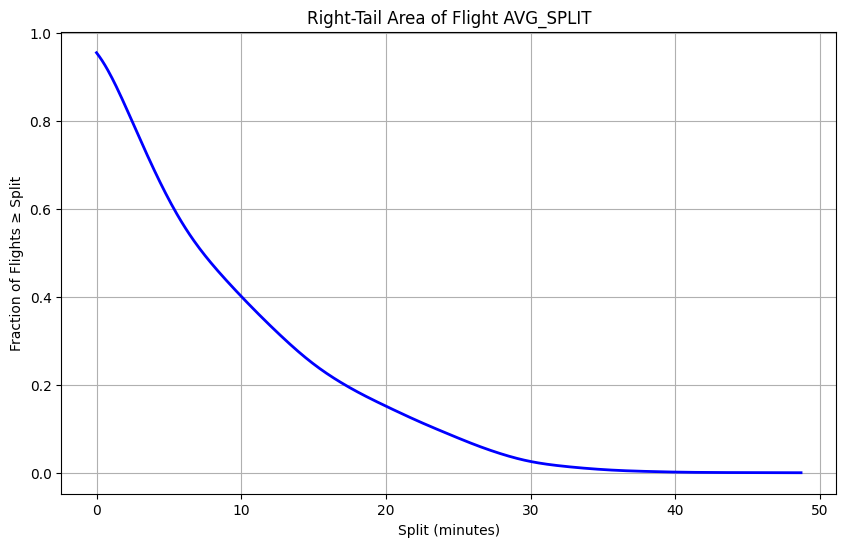

In [ ]:
# Building National Air System COngestion model
# ----------------------------------------------------

# Creating data copies
metar_datac = metar_data.copy()
sw_datac = sw_data.copy()
tnst_datac = tnst_data.copy()

# Sorting flight data by date time
tnst_datac.sort_values(by="SCHD_ARR_TIME_DATE_CENT", ascending=True, inplace=True)
tnst_datac.reset_index(drop=True, inplace=True)

# Adding average separation unit
merged_datac["AVG_SPLIT"] = (
    (merged_datac["SCHD_ARR_TIME_DATE_CENT"].shift(-1)-merged_datac["SCHD_ARR_TIME_DATE_CENT"]).dt.total_seconds() / 60
).rolling(10).mean()

# Prepare data (remove NaNs and negative splits)
vals = merged_datac["AVG_SPLIT"].dropna()
vals = vals[vals >= 0]

# Build a KDE (smoothed density function)
kde = gaussian_kde(vals, bw_method='scott')  # bandwidth can be tuned

# Optional: restrict KDE to positive splits only
kde.set_bandwidth(bw_method=kde.factor)

# Define a function to return density for any split value
def split_density(x):
    """
    Returns the density at split x (in minutes)
    """
    x = np.atleast_1d(x)  # ensure array-like
    x[x < 0] = 0           # clip negative values
    return kde(x)

# Define a function to compute the area under the curve from given split to the right
def right_tail_area(split_value, x_max=None, num_points=1000):
    """
    Computes the area under the KDE curve from split_value to x_max
    """
    if x_max is None:
        x_max = vals.max()  # use max value of your data by default
    x = np.linspace(split_value, x_max, num_points)
    y = kde(x)
    area = np.trapezoid(y, x)
    return area

# Define histogram bins (1-minute width)
bins = np.arange(0, vals.max() + 1, 1)  # 0, 1, 2, ..., max+1

# Plotting the density for visualization
x_plot = np.linspace(0, vals.max(), 1000)
plt.figure(figsize=(10,6))
# Plot histogram as bars (density=True scales to match KDE)
plt.hist(vals, bins=bins, density=True, alpha=0.5, color='gray', edgecolor='black', label="Buckets")
# Plot KDE line
plt.plot(x_plot, kde(x_plot), label="Density")
plt.title("Density of Flight AVG_SPLIT")
plt.xlabel("AVG_SPLIT (minutes)")
plt.ylabel("Density")
plt.grid(True)
plt.show()

# Compute right-tail area for a range of splits
x_range = np.linspace(0, vals.max(), 500)  # splits from 0 to max
right_tail = np.array([np.trapezoid(kde(np.linspace(xi, vals.max(), 500)), 
                                np.linspace(xi, vals.max(), 500)) for xi in x_range])

# Plotting the right-tail area
plt.figure(figsize=(10,6))
plt.plot(x_range, right_tail, color='blue', linewidth=2)
plt.title("Right-Tail Area of Flight AVG_SPLIT")
plt.xlabel("Split (minutes)")
plt.ylabel("Fraction of Flights ≥ Split")
plt.grid(True)
plt.show()
